In [31]:
"""
Importing Libraries
These will be used for numerical operations, plotting, animating, timng, and priority queue operations
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import time
import heapq

# Formalism

The state is represented by the coordinates and directions of the BeeBot. The map is not included in the state and only serves as a reference to check the BeeBots position on the map and weather it has reached its goal.

<u>BeeBot</u> (The State)
* Represented by a 1D array [bee_row, bee_col, bee_direction]
* bee_direction index corresponds to the following: 0 = North, 1 = East, 2 = South, 3 = West
* Initial State is randomly initialised, whereby map[bee_row][bee_col] == 0
* Goal state reached when map[bee_row][bee_col] == 2

<u>Map</u>
* represented by 2D array (m by n dimensions)
* Empty cell = 0
* Obstacles = -1
* BeeBot = 1
* Goal Cell = 2

<u>Conditions</u>
* 0 <= bee_row <= m
* 0 <= bee_col <= n
* 0 <= bee_direction <= 3
* map[bee_row][bee_col] != -1 (BeeBot cannot be on an obstacle labeled -1)

# Defining List of Possible Actions

## List of Actions Function

* This function sequences the possible actions based on the current direction that the BeeBot is facing
* The BeeBot has four actions: move forwards, move backwards, turn 90 degrees left, turn 90 degrees right
* The directions from the BeeBots perspective may not necessarily align with the cardinal directions on the map. For example, if BeeBot is currently facing East and it was to turn and move to its right, it would be moving further down (South) of the map rather than actually moving to the right (East) of the map.
* For the purpose of DFS, the sequence of actions are: 1) step back, 2) turn left, 3) turn right 4) step forward. This is to prioritise the step-forward action since DFS is Last-In-First-Out.

In [32]:
def ListOfActions(bee, action):
    x, y, direction = bee # obtaining the beebots current position and direction

    # define the movent deltas for each direction
    #these represent changes in x and y for each of the four cardinal directions

    movement_deltas = {
        0: (-1, 0), # Moving North decreases x by 1
        1: (0, 1), # Moving East increases y by 1
        2: (1, 0), # Moving SOuth increases x by 1
        3: (0, -1) # Moving West decreases y by 1
    }
    # Handle different actions
    if action == "move_forward":
        dx, dy = movement_deltas[direction]
        new_x, new_y = x + dx, y + dy
    elif action == "move_backward":
        dx, dy = movement_deltas[direction]
        new_x, new_y = x - dx, y - dy
    elif action == "rotate_left":
        new_direction = (direction - 1) % 4
        return (x, y, new_direction)
    elif action == "rotate_right":
        new_direction = (direction + 1) % 4
        return (x, y, new_direction)
    else:
        # if the move is invalid, return the current state unchanged
        return bee 

    # check if BeeBot is in bounds and not on an obstacle
    if 0 <= new_x < size and 0 <= new_y < size and map_matrix[new_x, new_y] != -1:
        return(new_x, new_y, direction)
    else:
        return bee
        

# Constructing Map and Initialising BeeBot

In [33]:
'''
size = int(input('Enter Map Size: '))
'''
# for ease, simply just defining a set size but can interchange with the line above
size = 10
map_matrix = np.zeros((size, size), dtype = int) # Creating MxN matrix filled with zeros

# Creating the Obstacles

num_neg_ones = (size*size)*0.2 # define number of obstacles (-1 values) (20% of the map)
neg_one_indices = [] # empty array to place the coordinates of the obstacles

# ensure that obstacles do not overwrite the initial BeeBotor goal positions
while len(neg_one_indices) < num_neg_ones:
    i, j = np.random.randint(0, size, 2) # randomly placing the obstacles on the map
    neg_one_indices.append((i,j))

# PLace the -1 values
for i, j in neg_one_indices:
    map_matrix[i, j] = -1 # overwriting the matrix of 0's with -1 values

while True:
    bee_x, bee_y = np.random.randint(0, size, 2)
    if map_matrix[bee_x, bee_y] == 0:
        break

# Randomly selecting the starting orientation of the BeeBot
bee_direction = np.random.randint (0, 4)

# Combining the Position and Orientation of the BeeBot
bee = (bee_x, bee_y, bee_direction)

# Randomly selecting where the goal is placed
while True:
    goal_x, goal_y = np.random.randint(0, size, 2)
    if map_matrix[goal_x, goal_y] == 0 and (goal_x, goal_y) != (bee_x, bee_y):
        break

## Creating a Print Board Function

In [34]:
# Creating a function to print the board with the obstackes, goal, and BeeBot as an arrow to indicate direction

def printState(display_board, title, bee, goal):
    bee_x, bee_y, bee_direction = bee
    goal_x, goal_y = goal

    # define colour map
    cmap = mcolors.ListedColormap(['black', 'white', 'green'])
    bounds = [-1.5, -0.5, 2, 3]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Plot the board
    plt.imshow(display_board, cmap=cmap, norm=norm)
    plt.grid()

    # Define the arrow properties for each direction
    arrow_props = {
        0: (0, -0.4), # North
        1: (0.4, 0), # East
        2: (0, 0.4),   # South
        3: (-0.4, 0)   # West
    }

    # Get the arrow direction
    dx, dy = arrow_props[bee_direction]

    # Plot an arrow over the bee to show its direction
    plt.annotate(
        '', xy=(bee_y + dx, bee_x + dy), xytext=(bee_y, bee_x),
        arrowprops=dict(facecolor='yellow', shrink=0.05, width=3)
    )

    plt.title(title)
    plt.show()

## Create and print initial State and final State

INITIAL STATE OF BOARD


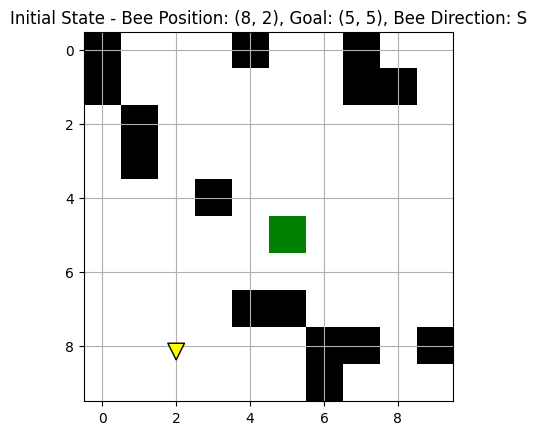

FINAL STATE OF BOARD


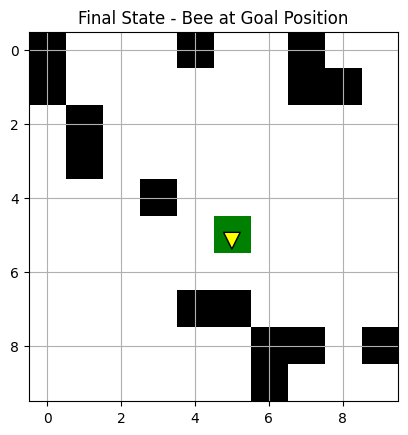

In [35]:
# Create initial state board
initial_state_board = map_matrix.copy()
initial_state_board[bee[0], bee[1]] = 1  # Place the bee-bot
initial_state_board[goal_x, goal_y] = 2  # Place the goal

cmps=['N','E','S','W']

# Print the initial board state with map, obstacles, bee, and goal
print("INITIAL STATE OF BOARD")
printState(initial_state_board, f"Initial State - Bee Position: ({bee[0]}, {bee[1]}), Goal: ({goal_x}, {goal_y}), Bee Direction: {cmps[bee[2]]}", bee, (goal_x, goal_y))

# Create final state board
final_state_board = map_matrix.copy()
final_state_board[goal_x, goal_y] = 2  # Bee at goal position

# Print the final board state with bee at the goal
print("FINAL STATE OF BOARD")
printState(final_state_board, "Final State - Bee at Goal Position", (goal_x, goal_y, bee[2]), (goal_x, goal_y))

# Creating the DFS Algorithm

In [36]:
# Start timing the execution
start_time = time.time()

# obtaining initial BeeBot and goal positions
initial_bee_state = (bee_x, bee_y, bee_direction)
goal_position = (goal_x, goal_y)

# Initialize data structures for DFS
visitedStates_dfs = set()  # Set to keep track of visited states
trackingDictionary_dfs = {}  # Dictionary to store path information
agenda_dfs = []  # Stack for DFS frontier
finalStateReached = False  # Flag to indicate if goal is reached

# Add initial state to agenda and mark as visited
agenda_dfs.append(initial_bee_state)  # Initial bee-bot position and orientation
visitedStates_dfs.add(initial_bee_state)  # Marking the initial state as visited

# Defining list of possible actions for the bee-bot
# reversing the list of actions as for DFS, Order is important: last action in list will be tried first due to DFS feature (last in first out).
actions = ["move_backward", "rotate_left", "rotate_right", "move_forward"]

# Creating the DFS loop
while agenda_dfs:
    # Raise the last state from agenda
    current_bee_state = agenda_dfs.pop()
    current_x, current_y, current_direction = current_bee_state

    # Check if the bee-bot is at the goal position
    if (current_x, current_y) == goal_position:
        finalStateReached = True
        break

    # Finding possible actions for the current state
    for action in actions:
        # Get the next state after applying the action
        next_bee_state = ListOfActions(current_bee_state, action)
        next_x, next_y, next_direction = next_bee_state
        '''
        Check if next state is valid:
        1. Within map boundaries
        2. Not an obstacle
        3. Not previously visited
        '''
        if (0 <= next_x < size and 0 <= next_y < size and (next_x, next_y) not in neg_one_indices):
            if next_bee_state not in visitedStates_dfs:
                trackingDictionary_dfs[next_bee_state] = (current_bee_state, action) # Store the path information for backtracking
                agenda_dfs.append(next_bee_state) # Add new state to agenda
                visitedStates_dfs.add(next_bee_state) # Mark state as visited

# Calculate and print execution time
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

Execution time: 0.0005 seconds


***The final state is reached***
Actions to reach the goal:
move_forward
rotate_right
move_forward
move_forward
rotate_right
move_forward
move_forward
move_forward
move_forward
move_forward
rotate_right
move_forward
move_forward
rotate_right
move_forward
move_forward
rotate_right
move_forward
rotate_right
move_backward
rotate_right
move_forward
move_forward
rotate_right
move_backward
rotate_left
move_forward
move_forward
move_forward
move_forward
move_forward
move_forward
rotate_right
move_backward
rotate_right
move_forward
move_forward
move_forward
move_forward

Displaying Bee's Movement:


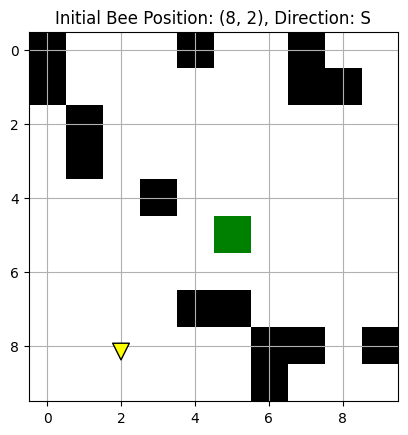

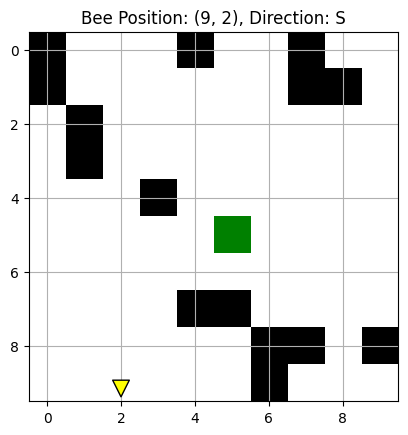

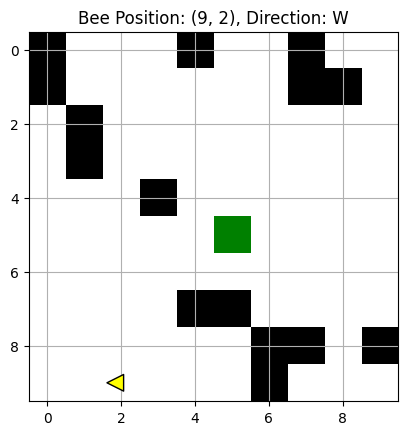

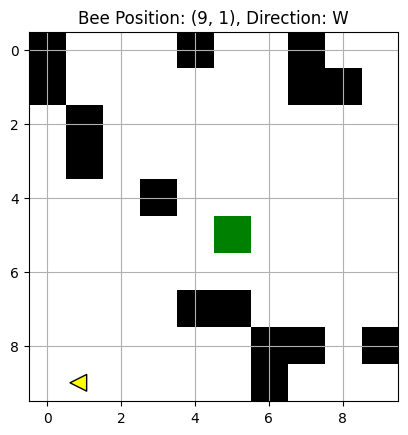

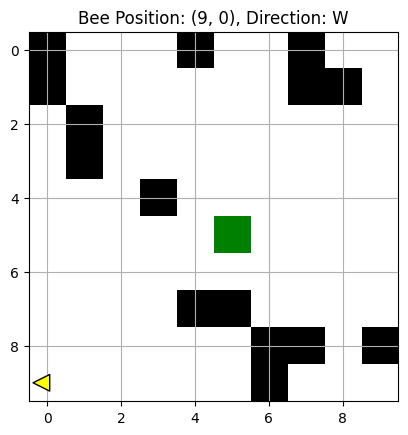

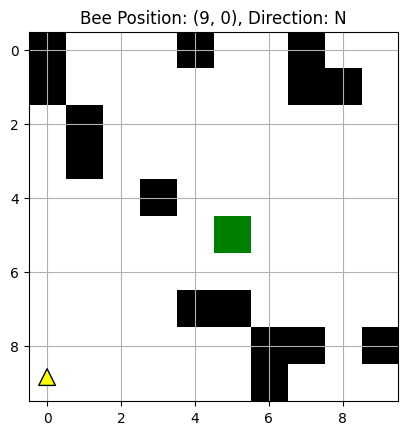

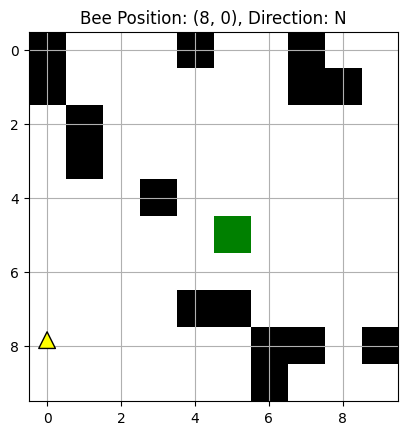

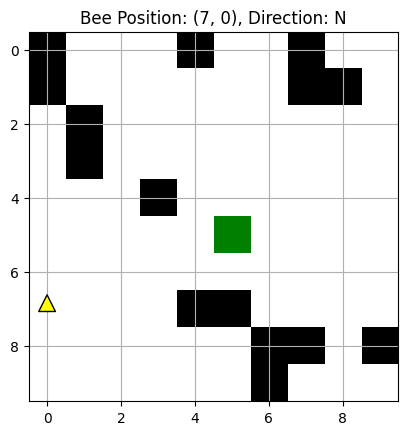

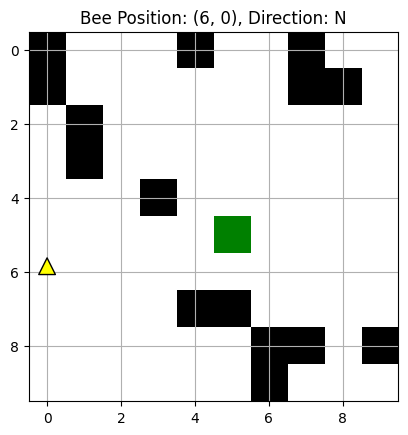

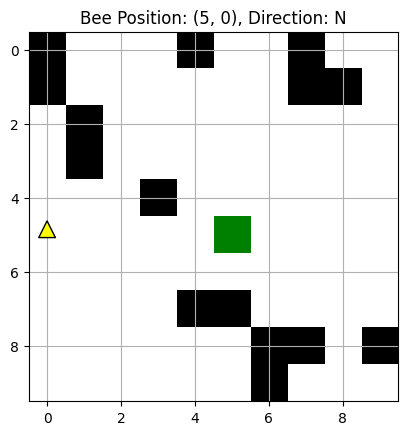

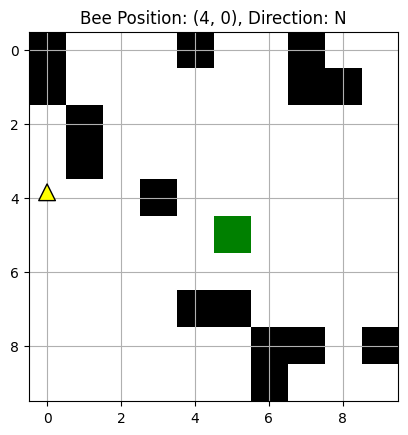

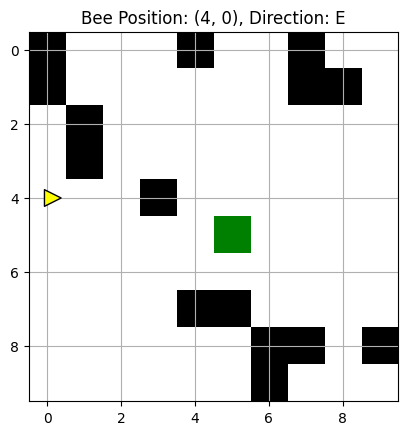

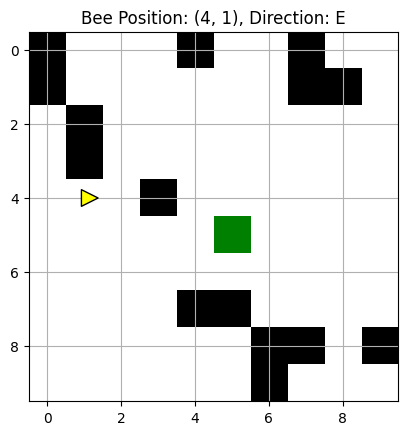

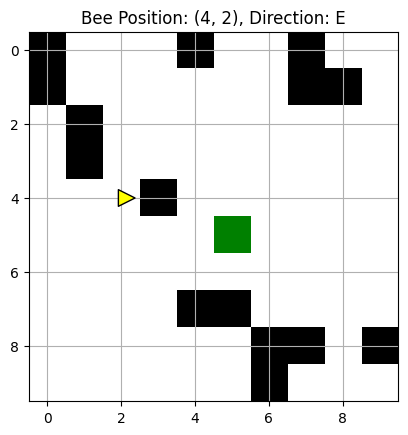

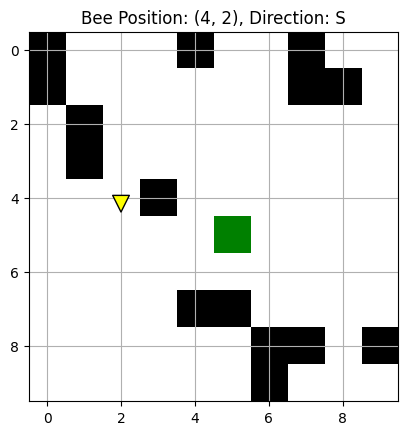

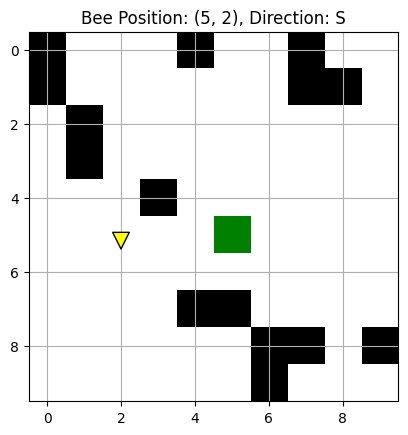

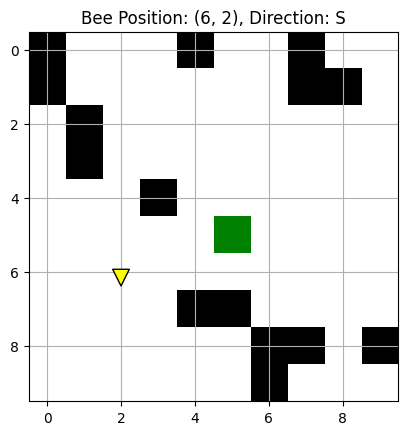

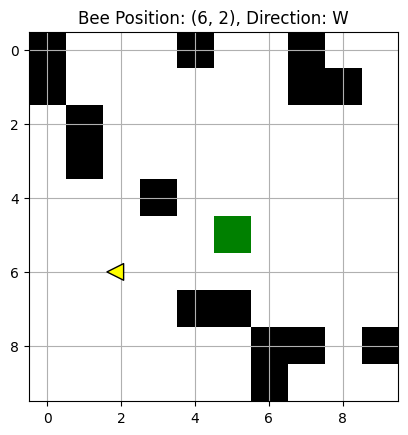

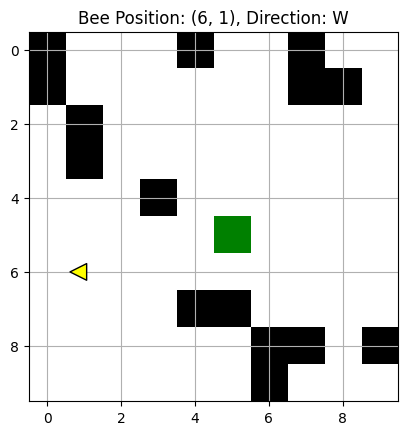

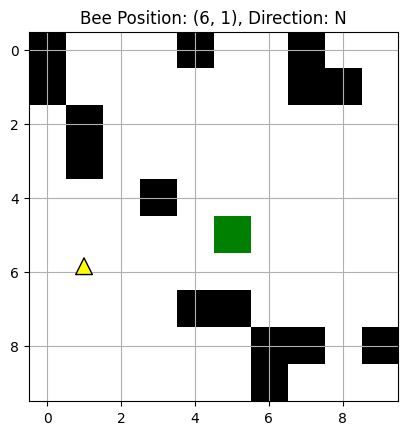

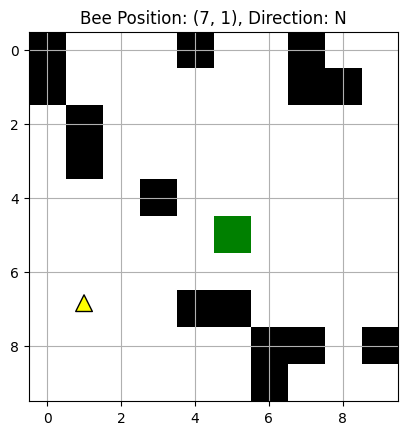

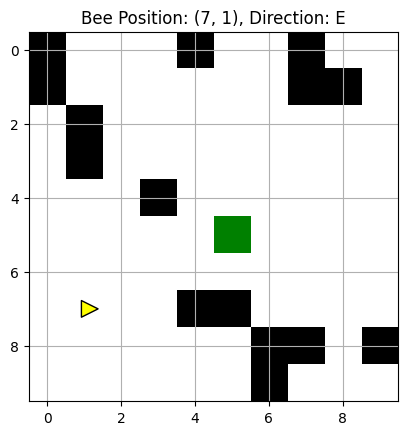

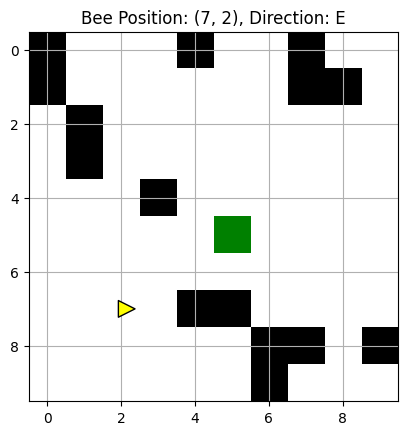

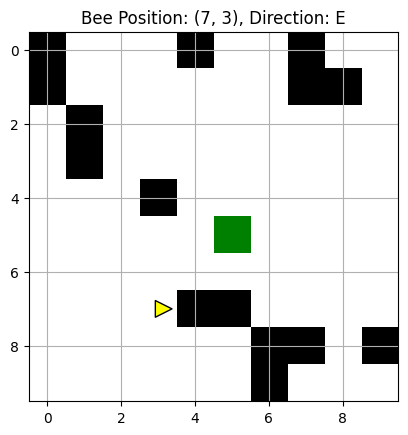

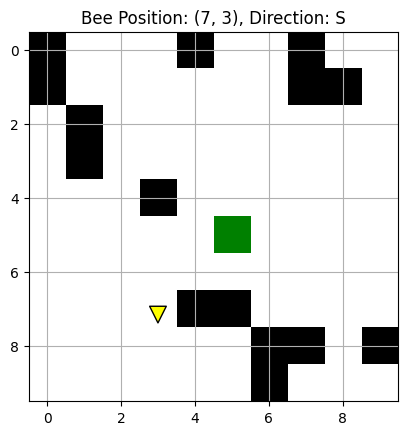

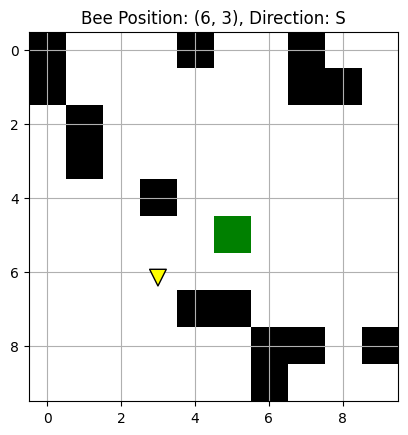

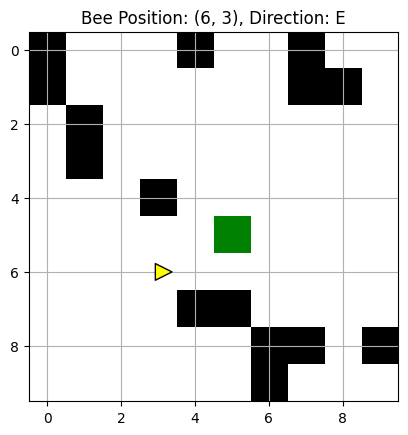

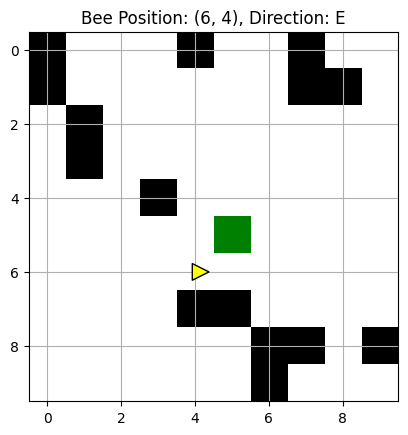

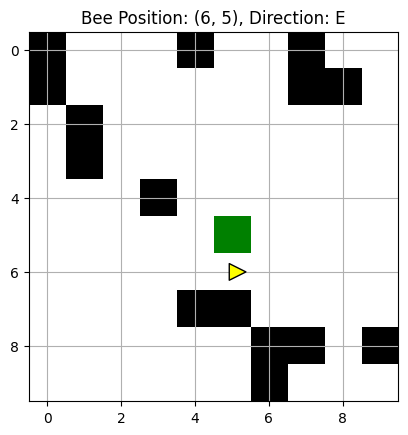

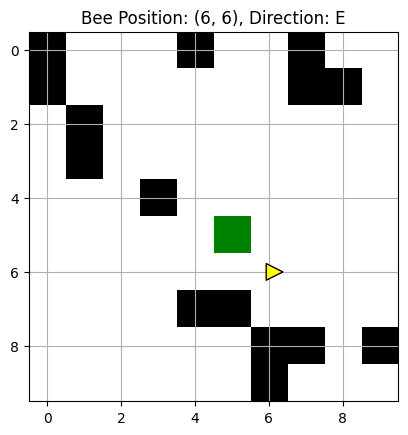

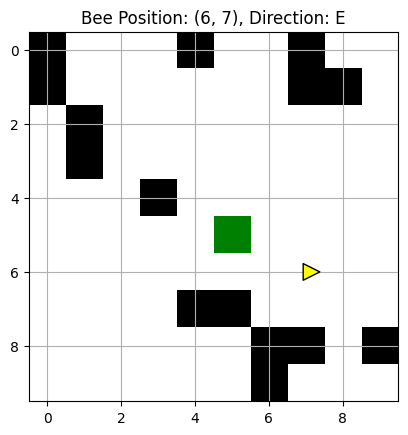

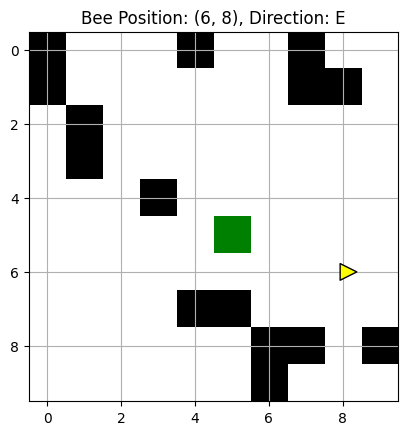

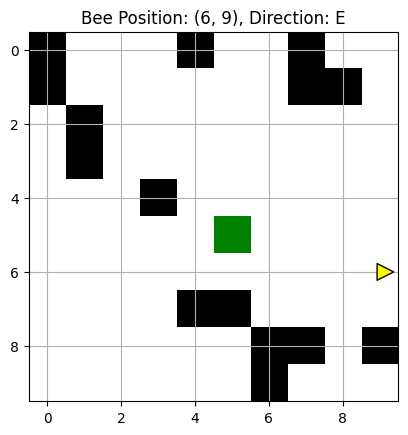

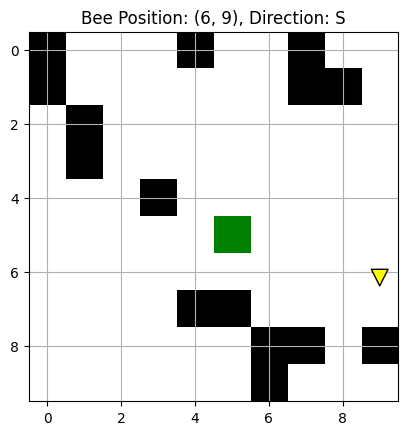

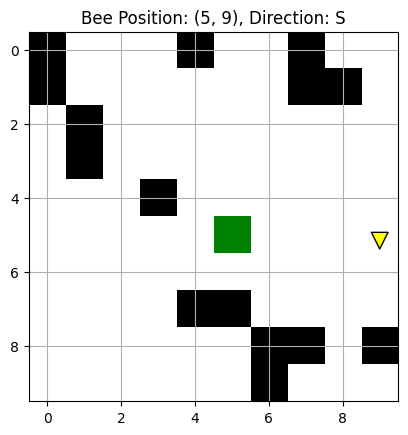

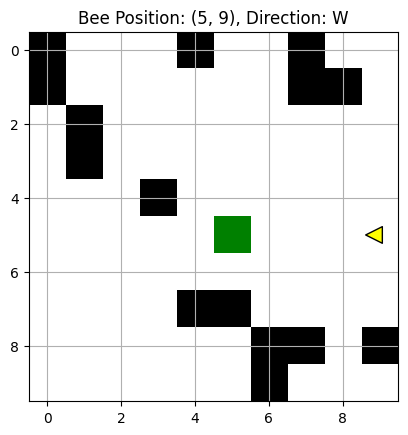

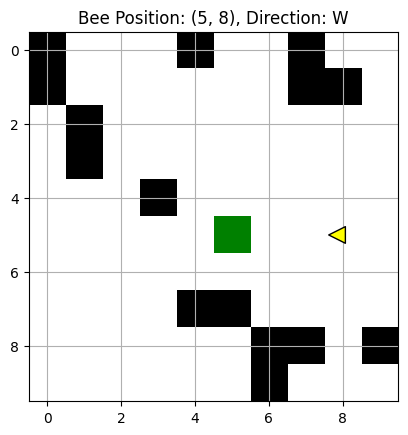

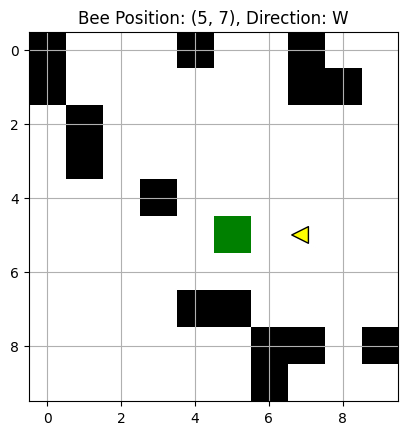

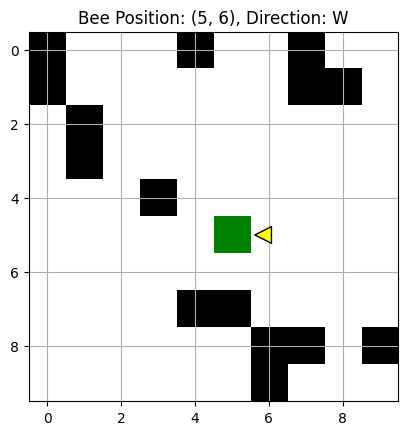

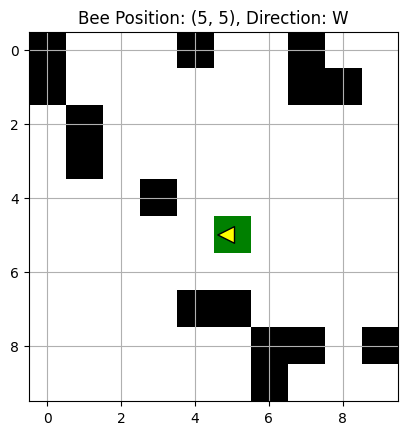

In [37]:
# Display list of actions takent by BeeBot to reach the goal and visualise the map at each step

def reconstruct(tracking_dict, initial_state, goal_state, final_state_reached):
    # Check if a path to the goal was found
    if final_state_reached:
        print("***The final state is reached***")
        # Initialize empty lists to store the path and actions
        path = [] # Store the sequence of states
        actions_taken = [] # Store the sequence of actions

        # Start reconstruction from the goal state
        state = goal_state
        # Work backwards from goal to initial state
        while state != initial_state:
            # Check if current state exists in tracking dictionary
            if state not in tracking_dict:
                print(f"Error: State {state} not found in tracking dictionary.")
                return
            # Get the previous state and action that led to current state
            prev_state, action = tracking_dict[state]
            path.append(state)
            actions_taken.append(action)
            state = prev_state

        # Reverse to get the path in the correct order
        path.reverse()
        actions_taken.reverse()

        # Display the actions
        print("Actions to reach the goal:")
        for action in actions_taken:
            print(action)

        print("\nDisplaying Bee's Movement:")

        # Initialize the grid for visualization
        display_board = np.zeros((size, size), dtype=int)
        for (i, j) in neg_one_indices:
            display_board[i, j] = -1  # Add obstacles
        display_board[goal_x, goal_y] = 3  # Add goal

        # Display initial state
        bee_x, bee_y, bee_dir = initial_state
        printState(
            display_board,
            f"Initial Bee Position: ({bee_x}, {bee_y}), Direction: {cmps[bee_dir]}",
            bee=(bee_x, bee_y, bee_dir),
            goal=(goal_x, goal_y),
        )

        # Display each step of the path
        for step in path:
            bee_x, bee_y, bee_dir = step
            display_board = np.zeros((size, size), dtype=int)
            for (i, j) in neg_one_indices:
                display_board[i, j] = -1  # Add obstacles
            display_board[goal_x, goal_y] = 3  # Add goal

            # Visualize the current state
            printState(
                display_board,
                f"Bee Position: ({bee_x}, {bee_y}), Direction: {cmps[bee_dir]}",
                bee=(bee_x, bee_y, bee_dir),
                goal=(goal_x, goal_y),
            )
    else:
        print("***The final state was not reached***") # Print error message if no valid path was found to the goal


dfs_final_state_reached = finalStateReached # Store whether DFS successfully found a path to the goal state
dfs_goal_state = (goal_x, goal_y, current_direction)  # Replace with the actual goal state
reconstruct(trackingDictionary_dfs, initial_bee_state, dfs_goal_state, dfs_final_state_reached)

# A* Algorithm

### Evaluation Function
* Using Manhattan distance as it is the minimum number of cells the BeeBot has to move to reach the goal
* Hence, heuristic h is admissable since h(s)≤h\*(s) in any scenario, whereby h\* is the true cost to the goal

Execution time: 0.0007 seconds
***The final state is reached***
Actions to reach the goal:
move_backward
move_backward
move_backward
rotate_left
move_forward
move_forward
move_forward

Displaying Bee's Movement:


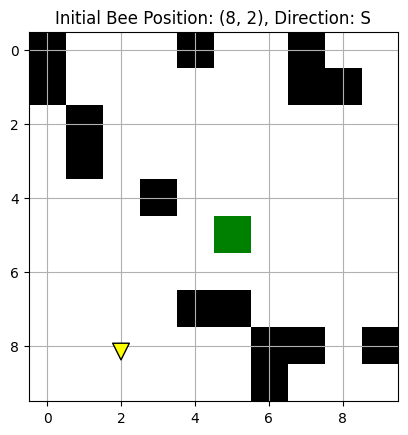

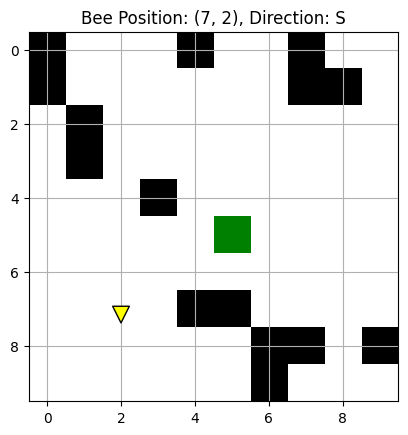

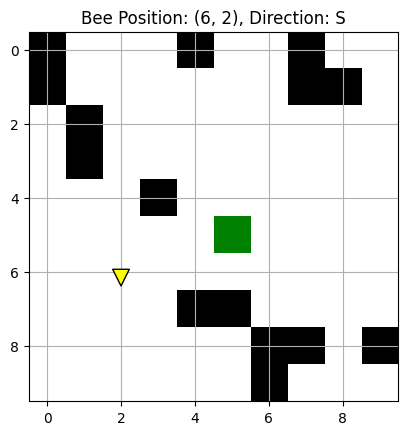

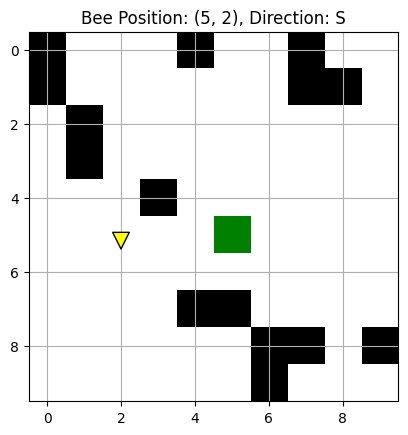

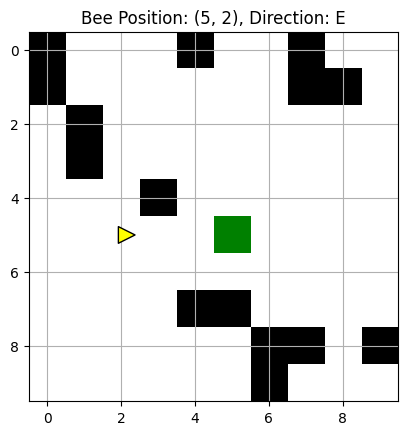

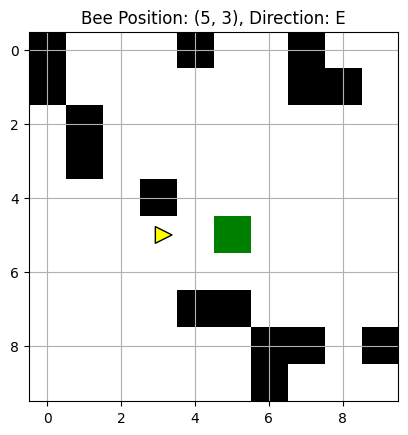

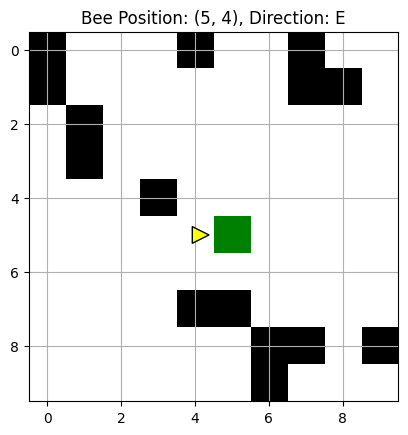

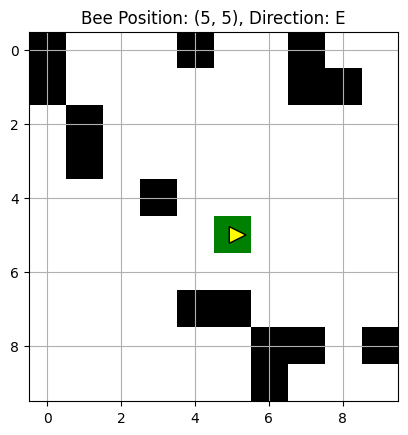

In [39]:
def manhattan_heuristic(current_x, current_y, goal_x, goal_y):
    # Manhattan distance heuristic (sum of absolute differences)
    return abs(current_x - goal_x) + abs(current_y - goal_y)

# Start timing the A* algorithm execution
start_time = time.time()

# Define possible actions in order of preference
actions = ["move_forward", "rotate_right", "rotate_left", "move_backward"]

# Initialize starting state and goal position
initial_bee_state = (bee_x, bee_y, bee_direction)
goal_position = (goal_x, goal_y)

# Initialize data structures for A* algorithm
visitedStates_A = set() # Set to track visited states
trackingDictionary_A = {} # Dictionary to store path information
agenda_A = [] # Priority queue for frontier states

g_score = {initial_bee_state: 0} # Dictionary to store cost from start to each node
initial_f_score = manhattan_heuristic(bee_x, bee_y, goal_x, goal_y) # Calculate initial f-score (g_score + heuristic)

# Add the initial state to the agenda as a tuple
# Format: (f_score, g_score, state) - f_score used for priority
heapq.heappush(agenda_A, (initial_f_score, g_score[initial_bee_state], initial_bee_state))
visitedStates_A.add(initial_bee_state)

finalStateReached = False
# Creating the A* loop
while agenda_A:
    # Get the state with the lowest f-score from the agenda
    f_score, current_g, current = heapq.heappop(agenda_A)
    current_x, current_y, current_dir = current
    # Check if current position meets goal position
    if (current_x, current_y) == (goal_x, goal_y):
        finalStateReached = True
        break
    # Mark current state as visited
    visitedStates_A.add(current)
    # Explore all possible actions from current state
    for action in actions:
        # Get next state after applying action
        next_bee_state = ListOfActions(current, action)
        next_x, next_y, next_dir = next_bee_state

        # Check if next state is valid (within bounds and not obstacle)
        if (0<= next_x < size and 0 <= next_y < size and ((next_x, next_y) not in neg_one_indices)):
            next_state = (next_x, next_y, next_dir)
            new_g = current_g + 1 # Cost to reach next state

            # Update if new path is better than previous one
            if next_state not in g_score or new_g < g_score[next_state]:
                g_score[next_state] = new_g
                f_score = new_g + manhattan_heuristic(next_x, next_y, goal_x, goal_y)

                heapq.heappush(agenda_A, (f_score, new_g, next_state))

                # Update `trackingDictionary_A`
                trackingDictionary_A[next_state] = (current, action)

    #print(f"Processing state: {current}")
    #print(f"Generated next state: {next_state} using action: {action}")

# Calculate and print execution time
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

# Store results for path reconstruction
a_star_final_state_reached = finalStateReached
a_star_goal_state = (goal_x, goal_y, current_dir)

# Reconstruct and visualize the path found by A*
reconstruct(trackingDictionary_A, initial_bee_state, a_star_goal_state, a_star_final_state_reached)